# STATS 507, Week 9-1 practice: scikit learn

### Problem 1 Your first machine learning project
This practice shows how scikit-learn can be used to recognize images of hand-written digits, from 0-9.

Load data: https://scikit-learn.org/1.5/modules/generated/sklearn.datasets.load_digits.html

Split data: https://scikit-learn.org/1.5/modules/generated/sklearn.model_selection.train_test_split.html

Create a SVM model: https://scikit-learn.org/dev/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

Evaluate the model performance:https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.classification_report.html



In [61]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt 

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

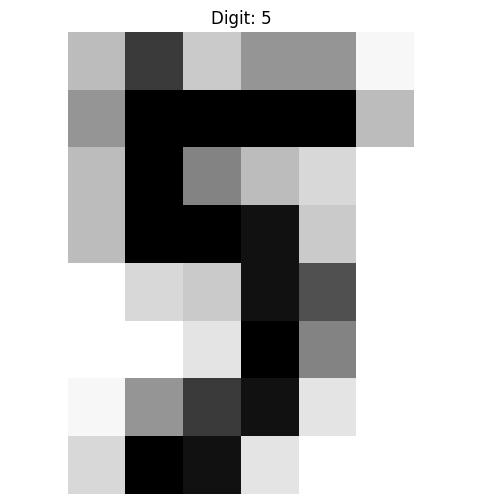

In [62]:
# Load the dataset
digits = datasets.load_digits()
print(digits.DESCR)
print(digits.data)

# Load the dataset to get x and y
X, y = datasets.load_digits(return_X_y=True)

# Visualize a sample digit
plt.figure(figsize=(6, 6))
plt.imshow(X[33].reshape(8, 8), cmap="Greys") # The input x
plt.title(f"Digit: {y[33]}")                  # The output label y
plt.axis('off')
plt.show()

In [63]:
from sklearn.model_selection import train_test_split
# Split the data into training (80%) and testing sets (20%) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(type(X_train))
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

<class 'numpy.ndarray'>
(1437, 64) (360, 64)
(1437,) (360,)


In [64]:
from sklearn import svm
# Create a SVM classifier with rbf kernal and Regularization parameter = 1
clf = svm.SVC(kernel='rbf', C=1)
clf.fit(X_train, y_train)

SVC(C=1)

In [65]:
# Evaluate the model 
from sklearn.metrics import classification_report
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



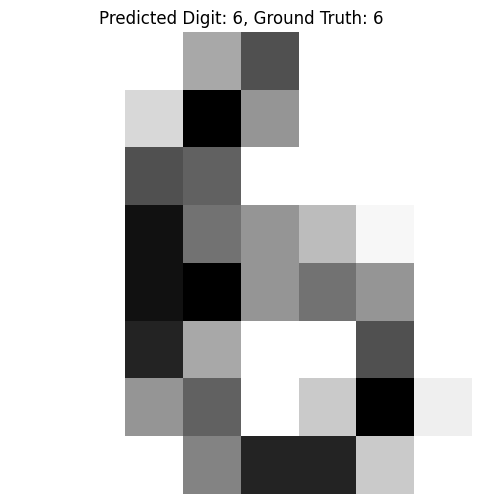

In [66]:
# Visualize the predicted digit
test_idx = 0
sample_digit = X_test[test_idx]
prediction = clf.predict([sample_digit])
plt.figure(figsize=(6, 6))
plt.imshow(sample_digit.reshape(8, 8), cmap="Greys")
plt.title(f"Predicted Digit: {prediction[0]}, Ground Truth: {y_test[test_idx]}")
plt.axis('off')
plt.show()

### Additional Practice

[ 0.  0.  0.  0. 12.  5.  0.  0.  0.  0.  0.  2. 16. 12.  0.  0.  0.  0.
  1. 12. 16. 11.  0.  0.  0.  2. 12. 16. 16. 10.  0.  0.  0.  6. 11.  5.
 15.  6.  0.  0.  0.  0.  0.  1. 16.  9.  0.  0.  0.  0.  0.  2. 16. 11.
  0.  0.  0.  0.  0.  3. 16.  8.  0.  0.]
1
Counter({np.int64(3): 183, np.int64(1): 182, np.int64(5): 182, np.int64(4): 181, np.int64(6): 181, np.int64(9): 180, np.int64(7): 179, np.int64(0): 178, np.int64(2): 177, np.int64(8): 174})


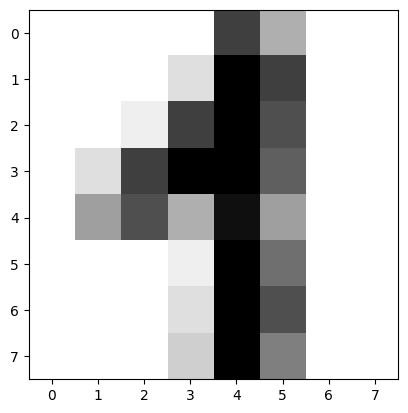

In [67]:
# Load the dataset; EDA 
digits = datasets.load_digits()
print(digits.data[42]) # Access the data of the 43rd digit image
print(digits.target[42]) # Access the label of the 43rd digit image
print(Counter(digits.target)) # Count the number of each digit in the dataset
plt.imshow(digits.images[42], cmap=plt.cm.gray_r)

In [68]:
digits.data.shape

(1797, 64)

In [69]:
# Create classifier model 
clf = svm.SVC() 
clf.fit(digits.data[:-1], digits.target[:-1])

SVC()

In [70]:
# use the trained model to predict 
clf.predict(digits.data[-1:])

array([8])

In [71]:
## LASSO Regression in scikit learn 

#generate synthetic data
    #200 points in 500 dimensions with only 10 non-zero coefficients
np.random.seed(0)
(n_samp, dim, k) = (200, 500, 10)
X = np.random.randn(n_samp, dim)
beta = np.zeros(dim)
inds = np.random.choice(np.arange(dim), size=k, replace=False)
beta[inds] = 5*np.random.randn(k)
y = np.dot(X, beta) + 0.1*np.random.randn(n_samp)

#split data into train and test set 
    #training data typically larger proportion than test data
X_train, y_train = X[:(n_samp//2), :], y[:(n_samp//2)]
X_test, y_test = X[(n_samp//2):, :], y[(n_samp//2):]

#import and train the model 
    #alpha controls regularization strength
    #larger alpha --> sparser coefficients
from sklearn.linear_model import Lasso 
lasso = Lasso(alpha = 0.1)
lasso.fit(X_train, y_train)

#predict on the test set
y_pred_lasso = lasso.predict(X_test)
from sklearn.metrics import r2_score 
r2_score(y_test, y_pred_lasso)

0.9991915055964717

Text(0, 0.5, 'petal ratio')

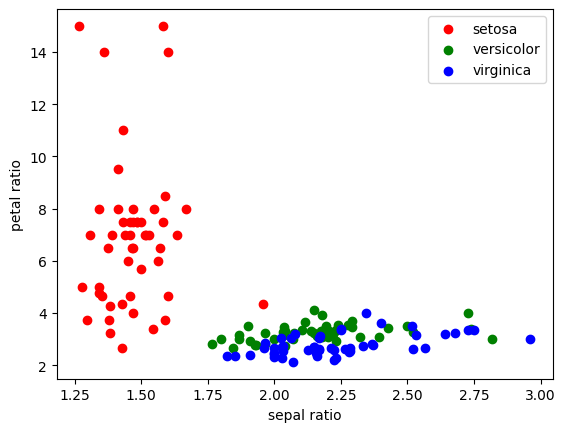

In [72]:
iris = datasets.load_iris()
X = iris.data 
y = iris.target 
sepal_ratio = X[:,0]/X[:,1]
petal_ratio = X[:,2]/X[:,3]
colors = ['red', 'green', 'blue']
for i in np.unique(y):
    plt.scatter(sepal_ratio[y==i], petal_ratio[y==i], 
                c=colors[i])
plt.legend(('setosa', 'versicolor', 'virginica'))
plt.xlabel('sepal ratio')
plt.ylabel('petal ratio')

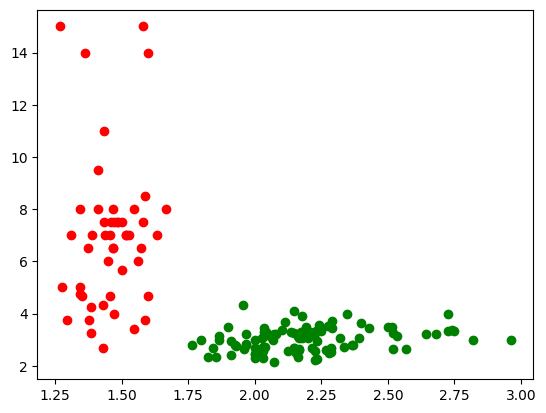

In [73]:
## Unsupervised Learning: k-GMM in sklearn 
from sklearn import mixture 
R = np.stack([sepal_ratio, petal_ratio], axis=1)
#incorrect number of components
gmm = mixture.GaussianMixture(n_components=2, n_init=10, 
                              covariance_type='full')
gmm.fit(R)


labs = gmm.predict(R)
for i in np.unique(labs):
    plt.scatter(sepal_ratio[labs==i], petal_ratio[labs==i], 
                c=colors[i])


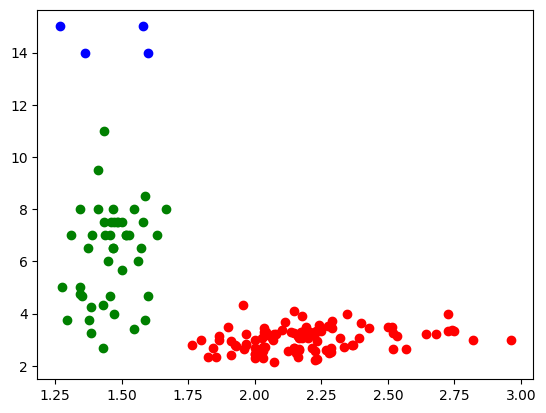

In [74]:
R = np.stack([sepal_ratio, petal_ratio], axis=1)
#still looks incorrect; using "ratios" R
gmm = mixture.GaussianMixture(n_components=3, n_init=10, 
                              covariance_type='full')
gmm.fit(R)

labs = gmm.predict(R)
for i in np.unique(labs):
    plt.scatter(sepal_ratio[labs==i], petal_ratio[labs==i], 
                c=colors[i])

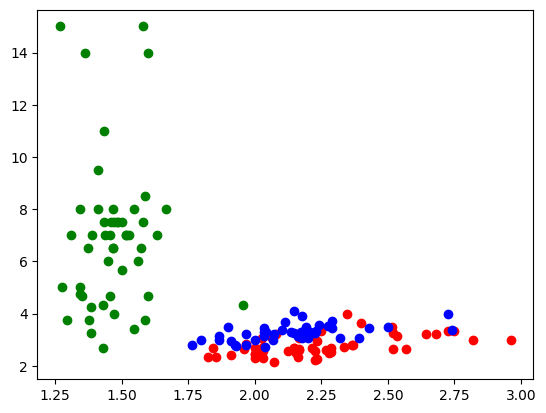

In [75]:
R = np.stack([sepal_ratio, petal_ratio], axis=1)
gmm = mixture.GaussianMixture(n_components=3, n_init=10, 
                              covariance_type='full')
gmm.fit(X) #now looks correct; using full data here

labs = gmm.predict(X)
for i in np.unique(labs):
    plt.scatter(sepal_ratio[labs==i], petal_ratio[labs==i], 
                c=colors[i])

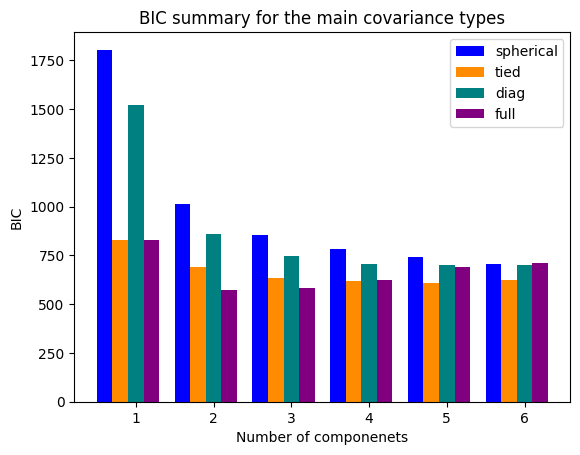

In [76]:
## Model Selection in sklearn 
iris = datasets.load_iris()
X = iris.data
y = iris.target
n_components_range = range(1, 7)
covar_types = ['spherical', 'tied', 'diag', 'full']
bics = np.zeros(shape=(len(covar_types), len(n_components_range)))
for i in range(len(covar_types)): 
    cvtype = covar_types[i]
    for j in range(len(n_components_range)): 
        n_comps = n_components_range[j]
        #fit GMM mixture with EM 
        gmm = mixture.GaussianMixture(n_components=n_comps, 
                                      covariance_type=cvtype)
        gmm.fit(X)
        bics[i,j] = gmm.bic(X)

barwidth = 0.2
inds = np.array(list(n_components_range))
colors = ['blue', 'darkorange', 'teal', 'purple']
for i in range(len(colors)): 
    plt.bar(inds + i*barwidth, bics[i,:], 
            width=barwidth, color=colors[i], 
            label=covar_types[i])
plt.xticks(inds + 2*barwidth, n_components_range)
plt.title("BIC summary for the main covariance types")
plt.xlabel("Number of componenets")
plt.ylabel("BIC")
_ = plt.legend()



Cross-validation scores: [0.36851507 0.41798764 0.39244032 0.44756796 0.53288475 0.33359285
 0.15836738 0.27872673 0.43098141 0.45781492]


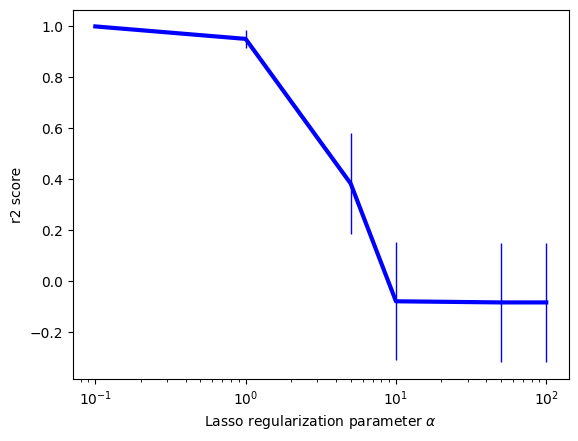

In [77]:
## Cross Validation in sklearn
from sklearn.model_selection import cross_val_score
np.random.seed(0)
(n_samp, dim, k) = (200, 500, 10)
X = np.random.randn(n_samp, dim)
beta = np.zeros(dim)
inds = np.random.choice(np.arange(dim), size=k, replace=False)
beta[inds] = 5*np.random.randn(k)
y = np.dot(X, beta) + 0.1*np.random.randn(n_samp)

lasso = Lasso(alpha=5)
scores = cross_val_score(lasso, X, y, cv=10)
print("Cross-validation scores:", scores)

#do same thing for different alphas
alphavals = np.array([0.1, 1, 5, 10.0, 50, 100])
mean_scores = np.zeros(alphavals.shape)
sd_scores = np.zeros(alphavals.shape)

for i in range(len(alphavals)):
    lasso = Lasso(alpha=alphavals[i])
    scores = cross_val_score(lasso, X, y, cv=10)
    mean_scores[i] = np.mean(scores)
    sd_scores[i] = np.std(scores)

plt.errorbar(alphavals, mean_scores, yerr=2*sd_scores, 
             color = 'blue', linewidth=3, elinewidth=1)
plt.xscale('log'); plt.ylabel('r2 score')
_ = plt.xlabel(r'Lasso regularization parameter $\alpha$')

0.5075234747132037

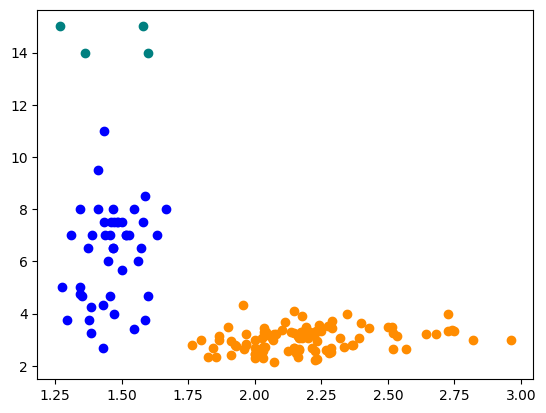

In [78]:
## Assessing Models: sklearn.metrics 
gmm = mixture.GaussianMixture(n_components=3, n_init=10,
                                covariance_type='full')
gmm.fit(R)
labs = gmm.predict(R)
for i in np.unique(labs):
    plt.scatter(sepal_ratio[labs==i], petal_ratio[labs==i], 
                c=colors[i])

from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(labs, iris.target) #ARI=1 perfect match; 0 random labels

In [79]:
## Model persistence: pickling model objects 
beta = np.zeros(dim)
inds = np.random.choice(np.arange(dim), size=k, replace=False)
beta[inds] = 5*np.random.randn(k)
(n_samp, dim, k) = (200, 500, 10)
X = np.random.randn(n_samp, dim)
y = np.dot(X, beta) + 0.1*np.random.randn(n_samp)

lasso = Lasso(alpha=1)
lasso.fit(X, y)

import pickle
filehandler = open('model.pkl', 'wb')
pickle.dump(lasso, filehandler)

In [80]:
filehandler2 = open('model.pkl', 'rb')
lasso = pickle.load(filehandler2)

In [81]:
print(lasso)

Lasso(alpha=1)
